# 📚 Mastering Question Answering with Transformers

## Learning Objectives
By the end of this notebook, you will:
1. **Understand** the fundamentals of Question Answering (QA) systems
2. **Learn** the difference between extractive and generative QA
3. **Master** using pre-trained QA models with Hugging Face Transformers
4. **Explore** the internals of QA models and how they work
5. **Practice** with real-world examples using SQuAD v2.0 models
6. **Build** confidence in implementing QA systems for your projects

---

## 🎯 Part 1: What is Question Answering?

### The Big Picture

Question Answering (QA) is a crucial NLP task where a model reads a piece of text (called **context**) and answers questions about it. Think of it as an automated reading comprehension test!

### Types of Question Answering

1. **Extractive QA** (What we'll focus on today)
   - The answer exists verbatim in the context
   - Model identifies the start and end positions of the answer
   - Example: "The sky is blue" → Q: "What color is the sky?" → A: "blue"

2. **Generative/Abstractive QA**
   - Model generates new text as the answer
   - May paraphrase or combine information
   - More complex but more flexible

3. **Open-Domain QA**
   - No specific context provided
   - Model must retrieve relevant information first
   - Then answer based on retrieved context

### SQuAD: The Gold Standard Dataset

**SQuAD (Stanford Question Answering Dataset)** is the benchmark for QA models:
- **SQuAD 1.1**: All questions have answers in the context
- **SQuAD 2.0**: Includes unanswerable questions (more realistic!)

Today, we'll use models trained on SQuAD 2.0, which can detect when a question cannot be answered from the given context.

## 🛠️ Setup and Imports

Let's start by setting up our environment. We'll suppress some warnings for cleaner output.

In [1]:
# Environment setup
import os
import warnings
warnings.filterwarnings('ignore')

# Set environment variable for OpenMP (Mac specific)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Core imports
import torch
import numpy as np
from typing import Dict, List, Tuple
import json
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import seaborn as sns
import transformers

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Transformers imports
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    pipeline,
    QuestionAnsweringPipeline
)

print(f"🔥 PyTorch Version: {torch.__version__}")
print(f"🤖 Transformers Version: {transformers.__version__}")

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("🍎 Using Apple Silicon GPU (MPS)")
else:
    device = torch.device('cpu')
    print("💻 Using CPU")

🔥 PyTorch Version: 2.9.1
🤖 Transformers Version: 4.57.3
🍎 Using Apple Silicon GPU (MPS)


## 🚀 Part 2: The Easy Way - Using Pipeline

The `pipeline` API is the simplest way to get started with QA. It handles all the complexity behind the scenes.

In [2]:
# Load a QA pipeline with a SQuAD v2.0 model
# We'll use deepset/roberta-base-squad2 - a RoBERTa model fine-tuned on SQuAD 2.0
print("Loading QA pipeline...")
qa_pipeline = pipeline(
    "question-answering",
    model="deepset/roberta-base-squad2",
    device=0 if device.type != 'cpu' else -1
)
print("✅ Pipeline ready!")

Loading QA pipeline...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use mps:0


✅ Pipeline ready!


### Example 1: Basic Question Answering

In [3]:
# Define context and question
context = """
The Transformer architecture was introduced in the paper "Attention is All You Need" by Vaswani et al. in 2017.
This revolutionary architecture replaced recurrent layers with self-attention mechanisms, allowing for much more
efficient parallel processing. The key innovation was the multi-head attention mechanism, which allows the model
to attend to different positions simultaneously. Transformers have since become the foundation for models like
BERT, GPT, and T5, revolutionizing natural language processing.
"""

questions = [
    "Who introduced the Transformer architecture?",
    "When was the Transformer introduced?",
    "What was the key innovation of Transformers?",
    "What models are based on Transformers?"
]

print("📝 Context:")
print(context.strip())
print("\n" + "="*80 + "\n")

# Answer each question
for question in questions:
    result = qa_pipeline(question=question, context=context)
    print(f"❓ Question: {question}")
    print(f"✅ Answer: {result['answer']}")
    print(f"📊 Confidence: {result['score']:.2%}")
    print(f"📍 Location: characters {result['start']} to {result['end']}")
    print("-" * 40)

📝 Context:
The Transformer architecture was introduced in the paper "Attention is All You Need" by Vaswani et al. in 2017.
This revolutionary architecture replaced recurrent layers with self-attention mechanisms, allowing for much more
efficient parallel processing. The key innovation was the multi-head attention mechanism, which allows the model
to attend to different positions simultaneously. Transformers have since become the foundation for models like
BERT, GPT, and T5, revolutionizing natural language processing.


❓ Question: Who introduced the Transformer architecture?
✅ Answer: Vaswani et al.
📊 Confidence: 84.26%
📍 Location: characters 89 to 103
----------------------------------------
❓ Question: When was the Transformer introduced?
✅ Answer: 2017
📊 Confidence: 97.58%
📍 Location: characters 107 to 111
----------------------------------------
❓ Question: What was the key innovation of Transformers?
✅ Answer: multi-head attention mechanism
📊 Confidence: 61.78%
📍 Location: charac

### Example 2: Handling Unanswerable Questions

SQuAD 2.0 models can detect when a question cannot be answered from the given context.

In [4]:
context_limited = """
Python is a high-level programming language known for its simplicity and readability.
It was created by Guido van Rossum and first released in 1991. Python supports multiple
programming paradigms including procedural, object-oriented, and functional programming.
"""

# Mix of answerable and unanswerable questions
test_questions = [
    "Who created Python?",  # Answerable
    "When was Python first released?",  # Answerable
    "What is the latest version of Python?",  # Not in context
    "How many users does Python have?",  # Not in context
]

print("📝 Context:")
print(context_limited.strip())
print("\n" + "="*80 + "\n")

for question in test_questions:
    result = qa_pipeline(
        question=question,
        context=context_limited,
        handle_impossible_answer=True  # Enable handling of unanswerable questions
    )
    
    print(f"❓ Question: {question}")
    if result['score'] < 0.01:  # Very low confidence indicates no answer
        print("❌ Cannot answer based on the given context")
    else:
        print(f"✅ Answer: {result['answer']}")
    print(f"📊 Confidence: {result['score']:.2%}")
    print("-" * 40)

📝 Context:
Python is a high-level programming language known for its simplicity and readability.
It was created by Guido van Rossum and first released in 1991. Python supports multiple
programming paradigms including procedural, object-oriented, and functional programming.


❓ Question: Who created Python?
✅ Answer: Guido van Rossum
📊 Confidence: 98.42%
----------------------------------------
❓ Question: When was Python first released?
✅ Answer: 1991
📊 Confidence: 97.28%
----------------------------------------
❓ Question: What is the latest version of Python?
✅ Answer: 
📊 Confidence: 88.14%
----------------------------------------
❓ Question: How many users does Python have?
✅ Answer: 
📊 Confidence: 94.99%
----------------------------------------


## 🔬 Part 3: Under the Hood - Understanding QA Models

Now let's dive deeper and understand how QA models actually work. We'll use `AutoModelForQuestionAnswering` to get more control over the process.

### How Extractive QA Works: The Technical Details

1. **Tokenization**: Convert question and context to tokens
2. **Format**: Create input as `[CLS] question [SEP] context [SEP]`
3. **Encoding**: Pass through transformer to get contextual embeddings
4. **Start/End Prediction**: Two linear layers predict:
   - Start logits: probability each token is the answer start
   - End logits: probability each token is the answer end
5. **Answer Extraction**: Find the span with highest combined score

In [5]:
# Load model and tokenizer separately for more control
model_name = "deepset/roberta-base-squad2"

print("Loading tokenizer and model...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)
model = model.to(device)
model.eval()  # Set to evaluation mode

print(f"✅ Model loaded: {model_name}")
print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading tokenizer and model...
✅ Model loaded: deepset/roberta-base-squad2
📊 Model parameters: 124,056,578


### Step-by-Step QA Process

In [6]:
# Define our question and context
context = "The Amazon rainforest produces about 20% of the world's oxygen and is home to 10% of known species on Earth."
question = "What percentage of the world's oxygen does the Amazon produce?"

print("📝 Context:", context)
print("❓ Question:", question)
print("\n" + "="*80 + "\n")

# Step 1: Tokenization
inputs = tokenizer(
    question,
    context,
    return_tensors="pt",
    max_length=384,
    truncation="only_second",
    padding="max_length"
)

print("Step 1: Tokenization")
print(f"Input shape: {inputs['input_ids'].shape}")
print(f"Number of tokens: {inputs['attention_mask'].sum().item()}")

# Let's see the actual tokens
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
print(f"\nFirst 30 tokens: {tokens[:30]}")
print("\n" + "-"*80 + "\n")

📝 Context: The Amazon rainforest produces about 20% of the world's oxygen and is home to 10% of known species on Earth.
❓ Question: What percentage of the world's oxygen does the Amazon produce?


Step 1: Tokenization
Input shape: torch.Size([1, 384])
Number of tokens: 41

First 30 tokens: ['<s>', 'What', 'Ġpercentage', 'Ġof', 'Ġthe', 'Ġworld', "'s", 'Ġoxygen', 'Ġdoes', 'Ġthe', 'ĠAmazon', 'Ġproduce', '?', '</s>', '</s>', 'The', 'ĠAmazon', 'Ġrain', 'forest', 'Ġproduces', 'Ġabout', 'Ġ20', '%', 'Ġof', 'Ġthe', 'Ġworld', "'s", 'Ġoxygen', 'Ġand', 'Ġis']

--------------------------------------------------------------------------------



In [7]:
# Step 2: Get model predictions
print("Step 2: Model Inference")

# Move inputs to device
input_ids = inputs['input_ids'].to(device)
attention_mask = inputs['attention_mask'].to(device)

# Get predictions
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

start_logits = outputs.start_logits.cpu()[0]
end_logits = outputs.end_logits.cpu()[0]

print(f"Start logits shape: {start_logits.shape}")
print(f"End logits shape: {end_logits.shape}")
print("\n" + "-"*80 + "\n")

Step 2: Model Inference
Start logits shape: torch.Size([384])
End logits shape: torch.Size([384])

--------------------------------------------------------------------------------



In [8]:
# Step 3: Find the answer span
print("Step 3: Finding Answer Span")

# Get the most likely start and end positions
start_idx = torch.argmax(start_logits).item()
end_idx = torch.argmax(end_logits).item()

print(f"Best start position: {start_idx}")
print(f"Best end position: {end_idx}")
print(f"Start token: '{tokens[start_idx]}'")
print(f"End token: '{tokens[end_idx]}'")

# Extract and decode the answer
answer_tokens = tokens[start_idx:end_idx + 1]
answer = tokenizer.convert_tokens_to_string(answer_tokens)

print(f"\n🎯 Final Answer: '{answer}'")

# Calculate confidence score
start_prob = torch.nn.functional.softmax(start_logits, dim=-1)[start_idx]
end_prob = torch.nn.functional.softmax(end_logits, dim=-1)[end_idx]
confidence = (start_prob * end_prob).item()

print(f"📊 Confidence: {confidence:.2%}")

Step 3: Finding Answer Span
Best start position: 21
Best end position: 22
Start token: 'Ġ20'
End token: '%'

🎯 Final Answer: ' 20%'
📊 Confidence: 79.23%


### Visualizing the Attention Scores

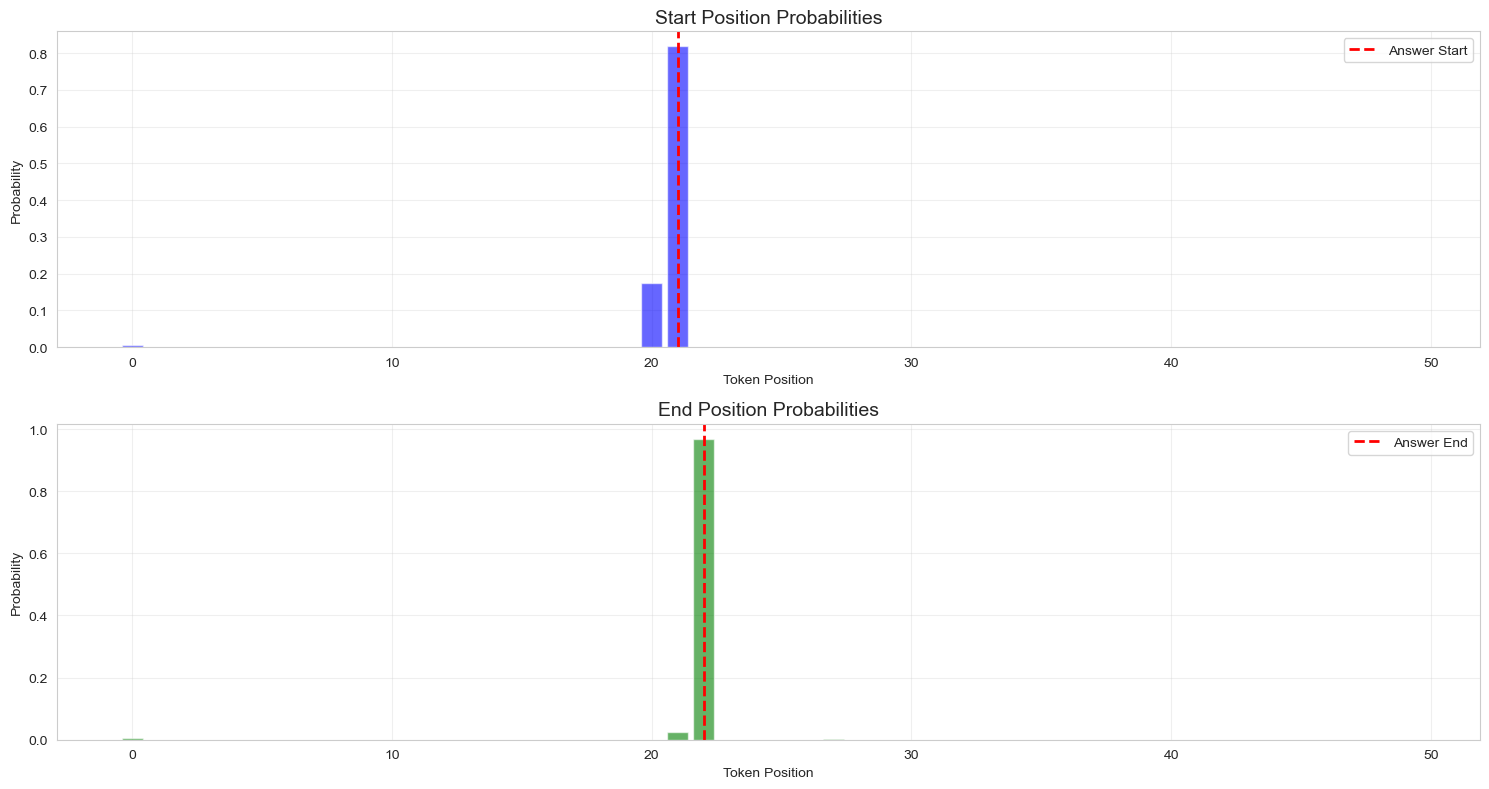


Answer tokens (21:23): ['Ġ20', '%']


In [9]:
def visualize_qa_scores(tokens, start_logits, end_logits, answer_start, answer_end, max_display=50):
    """
    Visualize the start and end scores for each token
    """
    # Convert logits to probabilities
    start_probs = torch.nn.functional.softmax(start_logits[:max_display], dim=-1)
    end_probs = torch.nn.functional.softmax(end_logits[:max_display], dim=-1)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
    
    # Plot start probabilities
    positions = range(len(start_probs))
    ax1.bar(positions, start_probs.numpy(), color='blue', alpha=0.6)
    if answer_start < max_display:
        ax1.axvline(x=answer_start, color='red', linestyle='--', linewidth=2, label=f'Answer Start')
    ax1.set_title('Start Position Probabilities', fontsize=14)
    ax1.set_xlabel('Token Position')
    ax1.set_ylabel('Probability')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot end probabilities
    ax2.bar(positions, end_probs.numpy(), color='green', alpha=0.6)
    if answer_end < max_display:
        ax2.axvline(x=answer_end, color='red', linestyle='--', linewidth=2, label=f'Answer End')
    ax2.set_title('End Position Probabilities', fontsize=14)
    ax2.set_xlabel('Token Position')
    ax2.set_ylabel('Probability')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add token labels (for first few tokens)
    if max_display <= 30:
        ax2.set_xticks(positions)
        ax2.set_xticklabels([t[:10] for t in tokens[:max_display]], rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Print the answer span
    print(f"\nAnswer tokens ({answer_start}:{answer_end+1}): {tokens[answer_start:answer_end+1]}")

# Visualize our example
visualize_qa_scores(tokens, start_logits, end_logits, start_idx, end_idx)

## 🎯 Part 4: Handling Long Contexts

Most transformer models have a maximum sequence length (typically 512 tokens). For longer contexts, we need to use a sliding window approach.

In [10]:
def answer_long_context(question, context, model, tokenizer, max_length=384, stride=128):
    """
    Handle long contexts using sliding window approach
    """
    # Tokenize with stride for overlapping windows
    inputs = tokenizer(
        question,
        context,
        max_length=max_length,
        truncation="only_second",
        stride=stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
        return_tensors="pt"
    )
    
    print(f"📊 Created {len(inputs['input_ids'])} chunks with stride {stride}")
    
    all_answers = []
    
    # Process each chunk
    for i in range(len(inputs['input_ids'])):
        chunk_input_ids = inputs['input_ids'][i:i+1].to(device)
        chunk_attention_mask = inputs['attention_mask'][i:i+1].to(device)
        
        with torch.no_grad():
            outputs = model(
                input_ids=chunk_input_ids,
                attention_mask=chunk_attention_mask
            )
        
        start_logits = outputs.start_logits[0].cpu()
        end_logits = outputs.end_logits[0].cpu()
        
        # Find best answer in this chunk
        start_idx = torch.argmax(start_logits).item()
        end_idx = torch.argmax(end_logits).item()
        
        if end_idx >= start_idx:
            score = (start_logits[start_idx] + end_logits[end_idx]).item()
            tokens = tokenizer.convert_ids_to_tokens(chunk_input_ids[0])
            answer = tokenizer.convert_tokens_to_string(tokens[start_idx:end_idx+1])
            
            all_answers.append({
                'answer': answer,
                'score': score,
                'chunk': i
            })
    
    # Return best answer across all chunks
    if all_answers:
        best_answer = max(all_answers, key=lambda x: x['score'])
        return best_answer
    return None

In [11]:
# Test with a longer context
long_context = """
Machine learning is a subset of artificial intelligence that focuses on building systems that learn from data.
Instead of being explicitly programmed, these systems improve their performance through experience.
The field emerged in the 1950s, with Arthur Samuel coining the term in 1959. He defined it as the "field of study
that gives computers the ability to learn without being explicitly programmed."

There are three main types of machine learning: supervised learning, unsupervised learning, and reinforcement learning.
Supervised learning uses labeled data to train models to make predictions. Common algorithms include linear regression,
decision trees, and neural networks. Unsupervised learning finds patterns in unlabeled data, with clustering and
dimensionality reduction being key techniques. Reinforcement learning trains agents to make decisions by rewarding
desired behaviors.

Deep learning, a subfield of machine learning, uses artificial neural networks with multiple layers. These networks
can automatically learn hierarchical representations from data. The breakthrough came in 2012 when AlexNet won the
ImageNet competition, demonstrating the power of deep convolutional neural networks. Since then, deep learning has
revolutionized computer vision, natural language processing, and many other fields.

The transformer architecture, introduced in 2017, has become the foundation for modern NLP. Models like BERT, GPT,
and T5 have achieved state-of-the-art results on numerous benchmarks. These models use self-attention mechanisms
to process sequences in parallel, making them much more efficient than previous recurrent architectures.
"""

long_question = "When was the transformer architecture introduced?"

print(f"📝 Context length: {len(long_context)} characters")
print(f"❓ Question: {long_question}\n")

result = answer_long_context(long_question, long_context, model, tokenizer)
if result:
    print(f"\n✅ Answer: {result['answer']}")
    print(f"📊 Score: {result['score']:.2f}")
    print(f"📍 Found in chunk: {result['chunk']}")

📝 Context length: 1659 characters
❓ Question: When was the transformer architecture introduced?

📊 Created 1 chunks with stride 128

✅ Answer:  2017
📊 Score: 15.11
📍 Found in chunk: 0


## 🔍 Part 5: Detecting Unanswerable Questions

SQuAD 2.0 models are trained to recognize when a question cannot be answered from the given context. Let's explore how this works.

In [12]:
def detect_unanswerable(question, context, model, tokenizer, threshold=0.0):
    """
    Detect if a question is answerable from the context
    """
    inputs = tokenizer(
        question, context,
        return_tensors="pt",
        max_length=384,
        truncation="only_second",
        padding=True
    )
    
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    
    start_logits = outputs.start_logits[0].cpu()
    end_logits = outputs.end_logits[0].cpu()
    
    # Check for null answer (CLS token has highest probability)
    # In BERT-like models, position 0 is the [CLS] token
    null_score = start_logits[0] + end_logits[0]
    
    # Find best non-null answer
    start_idx = torch.argmax(start_logits[1:]) + 1  # Skip CLS token
    end_idx = torch.argmax(end_logits[1:]) + 1
    
    if end_idx >= start_idx:
        answer_score = start_logits[start_idx] + end_logits[end_idx]
    else:
        answer_score = float('-inf')
    
    # Compare null score with answer score
    is_answerable = (answer_score - null_score) > threshold
    
    if is_answerable:
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
        answer = tokenizer.convert_tokens_to_string(tokens[start_idx:end_idx+1])
        return {
            'answerable': True,
            'answer': answer,
            'confidence': float(answer_score - null_score)
        }
    else:
        return {
            'answerable': False,
            'answer': None,
            'confidence': float(null_score - answer_score)
        }

In [13]:
# Test with various scenarios
test_context = """
The Great Wall of China is one of the most impressive architectural feats in human history.
Construction began in the 7th century BC, with major work done during the Ming Dynasty.
The wall stretches approximately 13,170 miles across northern China.
"""

test_cases = [
    "How long is the Great Wall of China?",  # Answerable
    "When did construction of the Great Wall begin?",  # Answerable  
    "How many tourists visit the Great Wall annually?",  # Not answerable
    "What materials were used to build the wall?",  # Not answerable
]

print("📝 Context:")
print(test_context.strip())
print("\n" + "="*80 + "\n")

for question in test_cases:
    result = detect_unanswerable(question, test_context, model, tokenizer)
    
    print(f"❓ Question: {question}")
    if result['answerable']:
        print(f"✅ Answer: {result['answer']}")
        print(f"📊 Confidence: {result['confidence']:.2f}")
    else:
        print("❌ Cannot answer from the given context")
        print(f"📊 Null confidence: {result['confidence']:.2f}")
    print("-" * 40)

📝 Context:
The Great Wall of China is one of the most impressive architectural feats in human history.
Construction began in the 7th century BC, with major work done during the Ming Dynasty.
The wall stretches approximately 13,170 miles across northern China.


❓ Question: How long is the Great Wall of China?
✅ Answer:  13,170 miles
📊 Confidence: 9.53
----------------------------------------
❓ Question: When did construction of the Great Wall begin?
✅ Answer:  7th century BC
📊 Confidence: 13.81
----------------------------------------
❓ Question: How many tourists visit the Great Wall annually?
❌ Cannot answer from the given context
📊 Null confidence: 9.72
----------------------------------------
❓ Question: What materials were used to build the wall?
❌ Cannot answer from the given context
📊 Null confidence: 4.71
----------------------------------------


## 📊 Part 6: Comparing Different QA Models

Let's compare different QA models to understand their strengths and weaknesses.

In [14]:
# Define models to compare
models_to_compare = [
    "deepset/roberta-base-squad2",
    "distilbert-base-cased-distilled-squad",
    "deepset/minilm-uncased-squad2"
]

# Test context and questions
eval_context = """
Albert Einstein was a German-born theoretical physicist who developed the theory of relativity.
He was born on March 14, 1879, in Ulm, Germany. Einstein received the Nobel Prize in Physics in 1921
for his services to theoretical physics. He published his special theory of relativity in 1905 and
the general theory of relativity in 1915. Einstein died on April 18, 1955, in Princeton, New Jersey.
"""

eval_questions = [
    "When was Einstein born?",
    "What did Einstein develop?",
    "When did Einstein receive the Nobel Prize?",
]

# Compare models
comparison_results = []

for model_name in models_to_compare:
    print(f"\n🤖 Testing: {model_name}")
    
    # Create pipeline for this model
    qa_pipe = pipeline(
        "question-answering",
        model=model_name,
        device=0 if device.type != 'cpu' else -1
    )
    
    model_results = {'model': model_name.split('/')[-1], 'answers': []}
    
    for question in eval_questions:
        result = qa_pipe(question=question, context=eval_context)
        model_results['answers'].append({
            'question': question,
            'answer': result['answer'],
            'score': result['score']
        })
        print(f"  Q: {question}")
        print(f"  A: {result['answer']} (confidence: {result['score']:.2%})")
    
    comparison_results.append(model_results)


🤖 Testing: deepset/roberta-base-squad2


Device set to use mps:0


  Q: When was Einstein born?
  A: March 14, 1879 (confidence: 95.73%)
  Q: What did Einstein develop?
  A: theory of relativity (confidence: 49.52%)
  Q: When did Einstein receive the Nobel Prize?
  A: 1921 (confidence: 90.85%)

🤖 Testing: distilbert-base-cased-distilled-squad


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/107 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use mps:0


  Q: When was Einstein born?
  A: March 14, 1879 (confidence: 95.79%)
  Q: What did Einstein develop?
  A: the theory of relativity (confidence: 49.12%)
  Q: When did Einstein receive the Nobel Prize?
  A: 1921 (confidence: 99.09%)


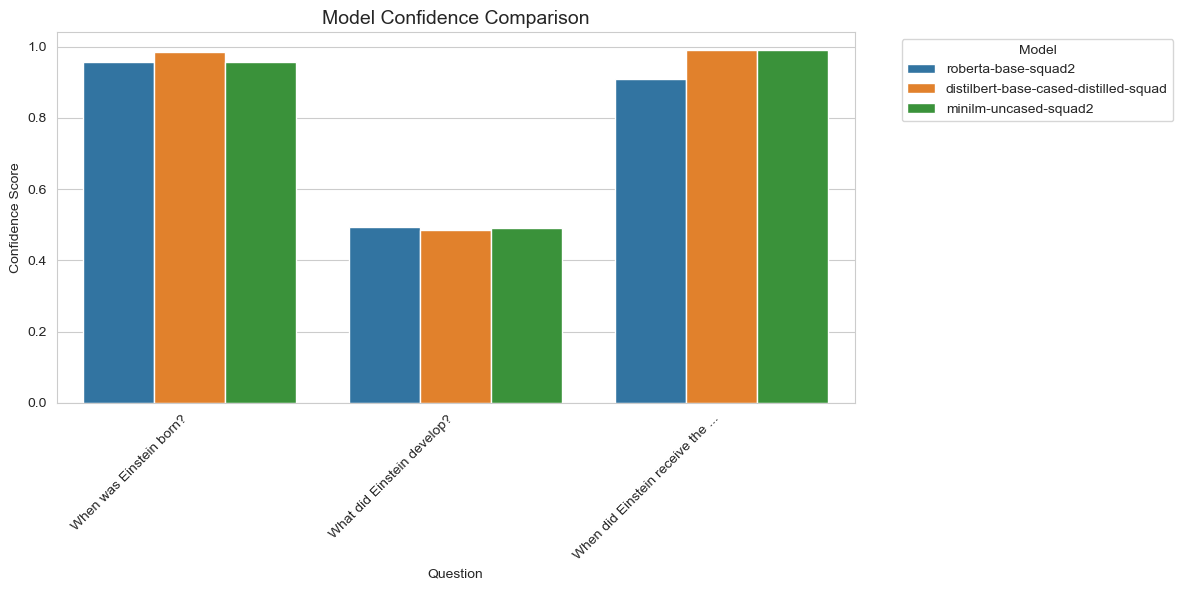


📊 Model Performance Summary
                                       Avg Confidence  Std Dev    Min    Max
Model                                                                       
distilbert-base-cased-distilled-squad           0.821    0.290  0.486  0.991
minilm-uncased-squad2                           0.813    0.279  0.491  0.991
roberta-base-squad2                             0.787    0.254  0.495  0.957

📝 Detailed Answers
Model                             distilbert-base-cased-distilled-squad  \
Question                                                                  
What did Einstein develop?                         theory of relativity   
When did Einstein receive the ...                                  1921   
When was Einstein born?                                  March 14, 1879   

Model                                 minilm-uncased-squad2  \
Question                                                      
What did Einstein develop?         the theory of relativity   
W

In [15]:
# Visualize model comparison
import pandas as pd

# Create comparison dataframe
comparison_data = []
for model_result in comparison_results:
    for answer in model_result['answers']:
        comparison_data.append({
            'Model': model_result['model'],
            'Question': answer['question'][:30] + '...' if len(answer['question']) > 30 else answer['question'],
            'Answer': answer['answer'],
            'Confidence': answer['score']
        })

df_comparison = pd.DataFrame(comparison_data)

# Plot comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_comparison, x='Question', y='Confidence', hue='Model')
plt.title('Model Confidence Comparison', fontsize=14)
plt.ylabel('Confidence Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Summary table
print("\n📊 Model Performance Summary")
print("="*60)
summary = df_comparison.groupby('Model')['Confidence'].agg(['mean', 'std', 'min', 'max'])
summary.columns = ['Avg Confidence', 'Std Dev', 'Min', 'Max']
print(summary.round(3))

# Show all answers
print("\n📝 Detailed Answers")
print("="*60)
print(df_comparison.pivot_table(index='Question', columns='Model', values='Answer', aggfunc='first'))

## 🎮 Part 7: Interactive QA Demo

Let's create an interactive demo where you can test the QA system with different contexts!

In [16]:
def interactive_qa_demo():
    """
    Interactive QA demonstration with multiple contexts
    """
    # Sample contexts to choose from
    contexts = {
        "AI History": """Artificial Intelligence has a rich history dating back to the 1950s. 
        Alan Turing proposed the Turing Test in 1950. The term 'Artificial Intelligence' was 
        coined by John McCarthy in 1956 at the Dartmouth Conference. Early AI research focused 
        on problem solving and symbolic methods. The first AI winter occurred from 1974 to 1980.""",
        
        "Deep Learning": """Deep learning is a subset of machine learning that uses neural networks 
        with multiple layers. The concept dates back to the 1960s, but the breakthrough came in 2012 
        with AlexNet winning ImageNet. Key architectures include CNNs for vision, RNNs for sequences, 
        and Transformers for NLP. Geoffrey Hinton, Yann LeCun, and Yoshua Bengio won the Turing Award 
        in 2018 for their contributions.""",
        
        "Climate Change": """Climate change refers to long-term shifts in global temperatures and 
        weather patterns. While climate variations are natural, scientific evidence shows that human 
        activities have been the dominant driver since the mid-20th century. The primary cause is 
        the emission of greenhouse gases, with CO2 levels now over 420 ppm, the highest in 3 million years."""
    }
    
    # Display available contexts
    print("🎮 Interactive QA Demo")
    print("="*60)
    print("\nAvailable contexts:")
    for i, (name, context) in enumerate(contexts.items(), 1):
        print(f"{i}. {name}: {context[:80]}...")
    
    # Let's use Deep Learning context as an example
    selected_context = contexts["Deep Learning"]
    
    print("\n📝 Selected Context: Deep Learning")
    print(selected_context)
    
    # Example questions
    example_questions = [
        "When was the breakthrough in deep learning?",
        "Who won the Turing Award in 2018?",
        "What are the key architectures mentioned?",
        "What competition did AlexNet win?",
        "When did deep learning concepts originate?"
    ]
    
    print("\n🤔 Answering Questions:")
    print("="*60)
    
    for question in example_questions:
        result = qa_pipeline(question=question, context=selected_context)
        print(f"\n❓ {question}")
        print(f"✅ {result['answer']}")
        print(f"📊 Confidence: {result['score']:.2%}")

# Run the demo
interactive_qa_demo()

🎮 Interactive QA Demo

Available contexts:
1. AI History: Artificial Intelligence has a rich history dating back to the 1950s. 
        Al...
2. Deep Learning: Deep learning is a subset of machine learning that uses neural networks 
       ...
3. Climate Change: Climate change refers to long-term shifts in global temperatures and 
        we...

📝 Selected Context: Deep Learning
Deep learning is a subset of machine learning that uses neural networks 
        with multiple layers. The concept dates back to the 1960s, but the breakthrough came in 2012 
        with AlexNet winning ImageNet. Key architectures include CNNs for vision, RNNs for sequences, 
        and Transformers for NLP. Geoffrey Hinton, Yann LeCun, and Yoshua Bengio won the Turing Award 
        in 2018 for their contributions.

🤔 Answering Questions:

❓ When was the breakthrough in deep learning?
✅ 2012
📊 Confidence: 92.20%

❓ Who won the Turing Award in 2018?
✅ Geoffrey Hinton, Yann LeCun, and Yoshua Bengio
📊 Confidenc

## 🏆 Part 8: Best Practices and Tips

### Key Takeaways for Building QA Systems:

1. **Model Selection**:
   - Use SQuAD 2.0 models for handling unanswerable questions
   - RoBERTa-based models generally perform better than BERT
   - DistilBERT offers good speed/accuracy tradeoff

2. **Preprocessing**:
   - Clean and normalize text (remove extra spaces, fix encoding)
   - Consider context length limitations (typically 512 tokens)
   - Use sliding window for long documents

3. **Confidence Thresholds**:
   - Set appropriate thresholds based on your use case
   - Lower thresholds for exploratory applications
   - Higher thresholds for production systems

4. **Performance Optimization**:
   - Batch processing for multiple questions
   - Use GPU/MPS acceleration when available
   - Consider model quantization for deployment

5. **Error Handling**:
   - Always check for unanswerable questions
   - Validate answer boundaries
   - Handle edge cases (empty context, very long questions)

## 📚 Exercises for Practice

Try these exercises to reinforce your learning:

### Exercise 1: Multi-hop Questions
Create a system that can answer questions requiring information from multiple sentences.

In [17]:
# Exercise 1: Multi-hop reasoning
exercise_context = """
Marie Curie was born in Warsaw in 1867. She moved to Paris in 1891 to study at the Sorbonne.
Curie was the first woman to win a Nobel Prize. She won her first Nobel Prize in Physics in 1903,
which she shared with her husband Pierre Curie and Henri Becquerel. Her second Nobel Prize was
in Chemistry in 1911 for her discovery of radium and polonium.
"""

# Try answering these questions:
exercise_questions = [
    "Where was Marie Curie born?",
    "How many Nobel Prizes did Marie Curie win?",
    "What did Marie Curie discover?",
    "Who did she share her first Nobel Prize with?"
]

print("Exercise 1: Answer the following questions")
print("="*60)
print("Context:")
print(exercise_context)
print("\nYour task: Use the QA pipeline to answer these questions:")

# Your solution here:
for q in exercise_questions:
    # TODO: Use qa_pipeline to answer each question
    print(f"\nQ: {q}")
    result = qa_pipeline(question=q, context=exercise_context)
    print(f"\n❓ {question}")
    print(f"✅ {result['answer']}")
    print(f"📊 Confidence: {result['score']:.2%}")
    # result = qa_pipeline(...)
    # print(f"A: ...")

Exercise 1: Answer the following questions
Context:

Marie Curie was born in Warsaw in 1867. She moved to Paris in 1891 to study at the Sorbonne.
Curie was the first woman to win a Nobel Prize. She won her first Nobel Prize in Physics in 1903,
which she shared with her husband Pierre Curie and Henri Becquerel. Her second Nobel Prize was
in Chemistry in 1911 for her discovery of radium and polonium.


Your task: Use the QA pipeline to answer these questions:

Q: Where was Marie Curie born?

❓ When did Einstein receive the Nobel Prize?
✅ Warsaw
📊 Confidence: 80.65%

Q: How many Nobel Prizes did Marie Curie win?

❓ When did Einstein receive the Nobel Prize?
✅ Nobel Prize in Physics in 1903
📊 Confidence: 4.92%

Q: What did Marie Curie discover?

❓ When did Einstein receive the Nobel Prize?
✅ radium and polonium
📊 Confidence: 68.76%

Q: Who did she share her first Nobel Prize with?

❓ When did Einstein receive the Nobel Prize?
✅ Pierre Curie and Henri Becquerel
📊 Confidence: 58.65%


### Exercise 2: Build a Custom QA Function
Create a function that finds all possible answers in a text and ranks them by confidence.

In [21]:
# Exercise 2: Find multiple possible answers
def find_top_k_answers(question, context, k=3):
    """
    Find top-k possible answers with their confidence scores
    
    Hint: You'll need to:
    1. Tokenize the input
    2. Get model predictions
    3. Find top-k start and end positions
    4. Generate all valid combinations
    5. Return top-k answers by score
    """
    # TODO: Implement this function
    inputs = tokenizer(
        question, context,
        return_tensors="pt",
        max_length=384,
        truncation="only_second",
        padding=True
    )
    
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    start_logits = outputs.start_logits[0].cpu()
    end_logits = outputs.end_logits[0].cpu()

    top_k_starts = torch.topk(start_logits, k)
    top_k_ends = torch.topk(end_logits, k)

    candidates = []
    for start_idx in top_k_starts.indices:
        for end_idx in top_k_ends.indices:
            # The 30 is a hyperparameter for maximum answer length (in tokens).
            
            #   Why limit answer length?
            
            #   1. Extractive QA answers are typically short - In SQuAD dataset, most answers are just a few words (names, dates, short phrases). Very long spans are
            #   usually wrong.
            #   2. Prevents degenerate answers - Without a limit, the model might select the entire context as an "answer" if start and end logits happen to be high at
            #   distant positions.
            #   3. 30 tokens ≈ 20-25 words - This is generous enough to capture longer answers like full sentences, but prevents nonsensical multi-paragraph spans.
            if end_idx >= start_idx and (end_idx -start_idx) < 30:
                score = start_logits[start_idx] + end_logits[end_idx]
                candidates.append({
                    'start': start_idx.item(),
                    'end': end_idx.item(),
                    'score': score.item(),
                })

    candidates.sort(key=lambda x: x['score'], reverse=True)

    # Decode
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    results = []
    for candidate in candidates[:k]:
        answer_tokens = tokens[candidate['start']:candidate['end'] + 1]
        answer = tokenizer.convert_tokens_to_string(answer_tokens)
        results.append({
            'answer': answer,
            'score': candidate['score']
        })

    return results
    
# Test your function:
test_context = "Python was created by Guido van Rossum in 1991. Python 2.0 was released in 2000. Python 3.0 came out in 2008."
test_question = "When was Python released?"

answers = find_top_k_answers(test_question, test_context)
for i, ans in enumerate(answers, 1):
    print(f"{i}. {ans['answer']} (score: {ans['score']:.2f})")

1.  2000 (score: 9.56)
2.  1991. Python 2.0 was released in 2000 (score: 7.34)
3.  2000. Python 3.0 came out in 2008 (score: 6.79)


### Exercise 3: Implement Answer Validation
Create a function that validates if an extracted answer makes grammatical sense.

In [23]:
# Exercise 3: Answer validation
def validate_answer(question, answer):
    """
    Check if an answer is valid for the given question
    
    Consider:
    - Question type (Who, What, When, Where, Why, How)
    - Expected answer format
    - Length constraints
    """
    # TODO: Implement validation logic
    if not answer or len(answer.strip()) == 0:
        return False

    answer = answer.strip().lower()
    question = question.strip().lower()
    
    # Detect question type
    question_type = None
    if question.startswith("who"):
      question_type = "who"
    elif question.startswith("when"):
      question_type = "when"
    elif question.startswith("where"):
      question_type = "where"
    elif question.startswith("what"):
      question_type = "what"
    elif question.startswith("how many") or question.startswith("how much"):
      question_type = "how_many"
    elif question.startswith("how"):
      question_type = "how"
    elif question.startswith("why"):
      question_type = "why"
    
    # Validation rules based on question type
    if question_type == "who":
      # "Who" answers should NOT start with time/place indicators
      invalid_starts = ["in ", "on ", "at ", "during ", "before ", "after "]
      for invalid in invalid_starts:
          if answer.startswith(invalid):
              return False
      # Should not be just a number/year
      if answer.isdigit():
          return False
    
    elif question_type == "when":
      # "When" answers should contain time-related content
      time_indicators = [
          "19", "20", "18",  # Years
          "january", "february", "march", "april", "may", "june",
          "july", "august", "september", "october", "november", "december",
          "monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday",
          "year", "month", "day", "week", "century",
          "morning", "evening", "night", "afternoon",
          "before", "after", "during", "ago"
      ]
      has_time = any(ind in answer for ind in time_indicators)
      # Also accept pure numbers (could be years)
      if not has_time and not any(c.isdigit() for c in answer):
          return False
    
    elif question_type == "where":
      # "Where" answers should NOT be person names or dates
      # Check if it's just a year
      if answer.isdigit() and len(answer) == 4:
          return False
      # Should not start with time indicators
      time_starts = ["in 19", "in 20", "on january", "on february"]
      for ts in time_starts:
          if answer.startswith(ts):
              return False
    
    elif question_type == "how_many" or question_type == "how much":
      # Should contain a number
      if not any(c.isdigit() for c in answer):
          return False
    
    # General length constraints
    if len(answer) < 1:
      return False
    if len(answer.split()) > 50:  # Too long for a typical answer
      return False
    
    return True


# Test cases:
test_cases = [
    ("When was it built?", "1990"),  # Valid
    ("Who created it?", "in 1990"),  # Invalid
    ("Where is it located?", "John Smith"),  # Invalid
]

for q, a in test_cases:
    is_valid = validate_answer(q, a)
    print(f"Q: {q} | A: {a} | Valid: {is_valid}")

Q: When was it built? | A: 1990 | Valid: True
Q: Who created it? | A: in 1990 | Valid: False
Q: Where is it located? | A: John Smith | Valid: True


## 🎓 Conclusion

Congratulations! You've mastered the fundamentals of Question Answering with Transformers!

### What You've Learned:
✅ Understanding extractive QA vs other QA types  
✅ Using pipeline API for quick implementation  
✅ Deep dive into how QA models work internally  
✅ Handling long contexts with sliding windows  
✅ Detecting unanswerable questions  
✅ Comparing different QA models  
✅ Best practices for production systems  

### Next Steps:
1. **Fine-tune a QA model** on your own dataset
2. **Explore generative QA** with models like T5 or BART
3. **Build a retrieval-augmented QA system** combining search with QA
4. **Implement multilingual QA** using mBERT or XLM-R
5. **Deploy a QA API** using FastAPI or Flask

### Resources for Further Learning:
- [Hugging Face QA Course](https://huggingface.co/course/chapter7/7)
- [SQuAD Dataset Paper](https://arxiv.org/abs/1606.05250)
- [BERT Paper](https://arxiv.org/abs/1810.04805)
- [RoBERTa Paper](https://arxiv.org/abs/1907.11692)
- [Papers With Code - Question Answering](https://paperswithcode.com/task/question-answering)

### Remember:
- Start simple with pipelines, then dive deeper as needed
- Always validate your model's outputs
- Consider the trade-offs between accuracy and speed
- Test with diverse questions and contexts

Happy learning! 🚀 Keep experimenting and building amazing QA systems!